In [ ]:
import zipfile
import os
import glob

zip_path = '/content/Fire Smoke and Human Detector.v32i.yolov8-obb.zip'
extract_path = '/content/dataset/'

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f'Dataset extracted successfully to {extract_path}')
else:
    print(f'Error: {zip_path} not found. Please ensure the filename matches exactly.')

Dataset extracted successfully to /content/dataset/


In [ ]:
# Let's inspect the first label file to see the format
label_files = glob.glob(f'{extract_path}/**/*.txt', recursive=True)

if label_files:
    print(f'Found {len(label_files)} label files.')
    sample_label = label_files[0]
    print(f'Sample label file: {sample_label}')
    with open(sample_label, 'r') as f:
        content = f.read().strip()
        print('\nLabel Content:')
        print(content)

    # Basic logic to guess format
    parts = content.split('\n')[0].split()
    if len(parts) == 5:
        print('\nDetection: Standard YOLO format (class, x_center, y_center, width, height)')
    elif len(parts) > 5:
        print('\nDetection: Likely OBB (Oriented Bounding Box) format with multiple coordinates.')
else:
    print('No label files (.txt) found. Checking for data.yaml...')
    yaml_files = glob.glob(f'{extract_path}/*.yaml')
    print(f'YAML files found: {yaml_files}')

Found 9751 label files.
Sample label file: /content/dataset/README.roboflow.txt

Label Content:
Fire Smoke and Human Detector - v32 2024-03-19 4:34pm

This dataset was exported via roboflow.com on May 15, 2024 at 9:59 AM GMT

Roboflow is an end-to-end computer vision platform that helps you
* collaborate with your team on computer vision projects
* collect & organize images
* understand and search unstructured image data
* annotate, and create datasets
* export, train, and deploy computer vision models
* use active learning to improve your dataset over time

For state of the art Computer Vision training notebooks you can use with this dataset,
visit https://github.com/roboflow/notebooks

To find over 100k other datasets and pre-trained models, visit https://universe.roboflow.com

The dataset includes 9749 images.
Fire-smoke-human are annotated in YOLOv8 Oriented Object Detection format.

The following pre-processing was applied to each image:
* Auto-orientation of pixel data (with EXIF

In [ ]:
# Inspect a real label file instead of the README
actual_labels = [f for f in label_files if 'labels' in f]
if actual_labels:
    print(f"Inspecting: {actual_labels[0]}")
    with open(actual_labels[0], 'r') as f:
        print(f.read())
else:
    print("No label files found in the 'labels' directory.")

Inspecting: /content/dataset/train/labels/67_png_jpg.rf.97c90af7eedb7ba93663caa816f7038e.txt
1 0.4984375000000001 0.19843750000000004 0.3375 0.19843750000000004 0.3375 0.775 0.4984375000000002 0.775
1 0.64375 0.22656250000000008 0.50625 0.22656250000000008 0.5062500000000001 0.7671875 0.6437500000000002 0.7671875
1 0.875 0.1437500000000001 0.68125 0.1437500000000001 0.68125 0.5468750000000001 0.875 0.5468750000000002


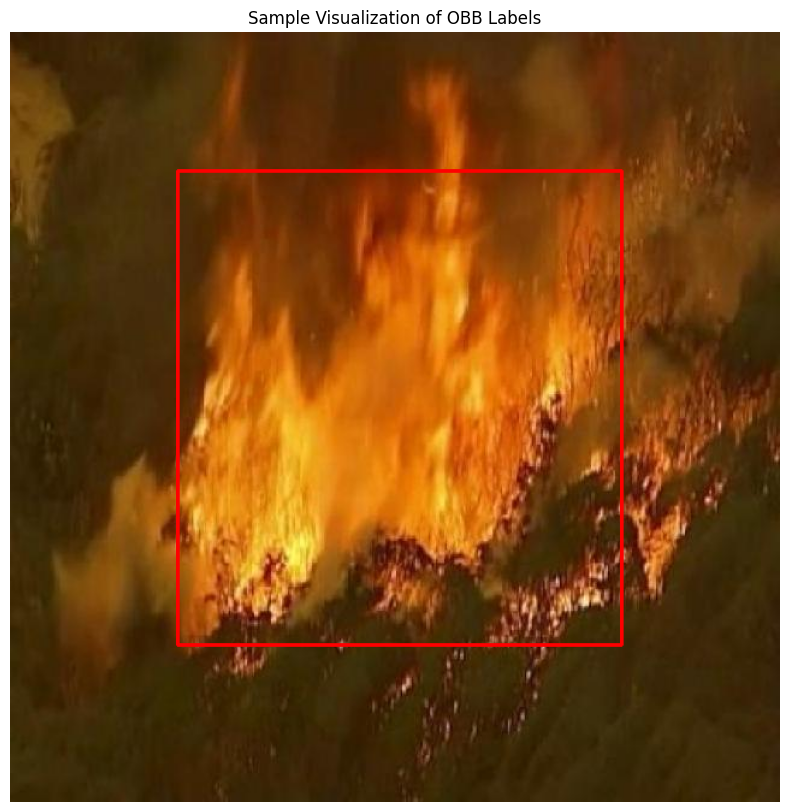

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Visualize one image with its Oriented Bounding Boxes
image_files = glob.glob(f'{extract_path}/train/images/*.jpg')
if image_files:
    image_path = image_files[0]
    label_path = image_path.replace('images', 'labels').replace('.jpg', '.txt')

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f.readlines():
                parts = list(map(float, line.strip().split()))
                if len(parts) >= 9:
                    # OBB format: class, x1, y1, x2, y2, x3, y3, x4, y4 (normalized)
                    pts = np.array(parts[1:]).reshape(-1, 2)
                    pts[:, 0] *= w
                    pts[:, 1] *= h
                    pts = pts.astype(np.int32)
                    cv2.polylines(img, [pts], isClosed=True, color=(255, 0, 0), thickness=2)

    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.title("Sample Visualization of OBB Labels")
    plt.axis('off')
    plt.show()
else:
    print("No images found for visualization.")

In [ ]:
!pip install ultralytics -q
from ultralytics import YOLO
import os

# Verify installation and hardware acceleration (GPU)
import ultralytics
ultralytics.checks()

Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 48.0/112.6 GB disk)


In [ ]:
import yaml
from ultralytics import YOLO

# Fix data.yaml paths
yaml_path = '/content/dataset/data.yaml'
with open(yaml_path, 'r') as f:
    data_cfg = yaml.safe_load(f)

# Update paths to absolute locations in this environment
data_cfg['path'] = '/content/dataset'
data_cfg['train'] = 'train/images'
data_cfg['val'] = 'valid/images'
data_cfg['test'] = 'test/images'

with open(yaml_path, 'w') as f:
    yaml.dump(data_cfg, f)

print('Updated data.yaml structure:')
print(data_cfg)

# Load the pretrained YOLOv8-OBB model
model = YOLO('yolov8s-obb.pt')

# Restart training with fixed paths
results = model.train(
    data=yaml_path,
    epochs=10,
    imgsz=640,
    batch=16,
    name='yolov8_obb_fire_smoke',
    device=0
)

Updated data.yaml structure:
{'path': '/content/dataset', 'train': 'train/images', 'val': 'valid/images', 'test': 'test/images', 'names': {0: 'fire', 1: 'human', 2: 'smoke'}}
Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, m

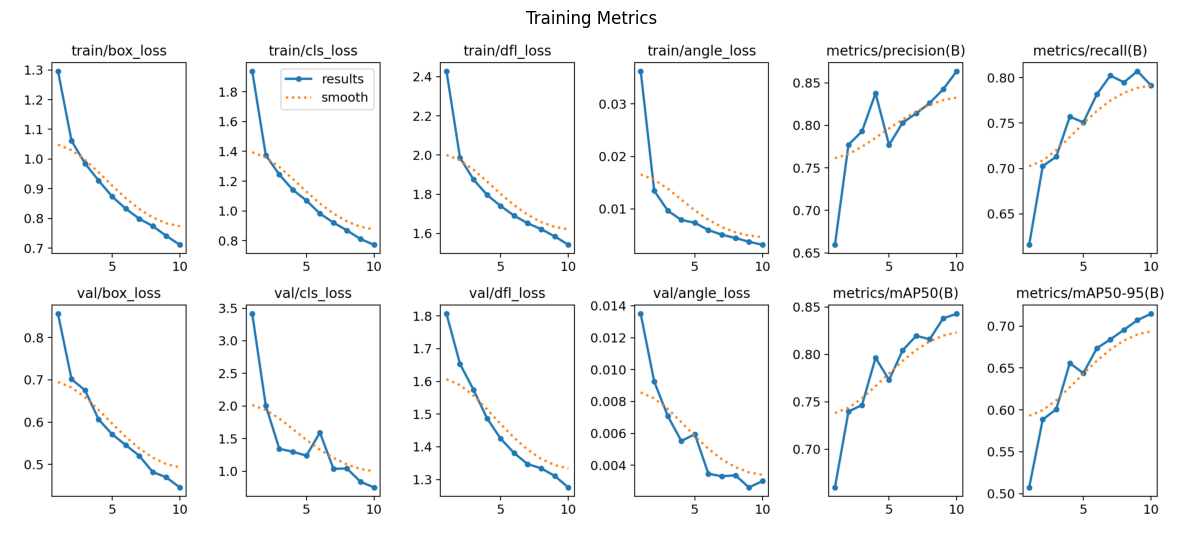

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob

# Display the training results plots (Loss, mAP, etc.)
results_dir = '/content/runs/obb/yolov8_obb_fire_smoke-4'
results_png = f'{results_dir}/results.png'

if os.path.exists(results_png):
    plt.figure(figsize=(15, 10))
    img = mpimg.imread(results_png)
    plt.imshow(img)
    plt.axis('off')
    plt.title("Training Metrics")
    plt.show()
else:
    print("Results plot not found.")

In [ ]:
# Validate the best model on the test set
metrics = model.val(split='test')

# For OBB models, metrics like mAP are accessed through the .box attribute
print(f"Test mAP50: {metrics.box.map50}")
print(f"Test mAP50-95: {metrics.box.map}")

Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1534.1±529.9 MB/s, size: 41.1 KB)
val: Scanning /content/dataset/test/labels.cache... 731 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 731/731 255.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 46/46 3.2it/s 14.2s
                   all        731       1935      0.847       0.75      0.827      0.613
                  fire        673        954      0.914      0.905      0.943      0.754
                 human        182        370      0.746      0.624      0.694      0.435
                 smoke        451        611       0.88      0.721      0.845      0.651
Speed: 1.4ms preprocess, 9.5ms inference, 0.0ms loss, 3.1ms postprocess per image
Results saved to /content/runs/obb/val-2
Test mAP50: 0.8270541378660493
Test mAP50-95: 0.6133880209632258



0: 640x640 1 fire, 2 humans, 1 smoke, 19.3ms
1: 640x640 3 fires, 2 smokes, 19.3ms
2: 640x640 4 fires, 1 human, 1 smoke, 19.3ms
Speed: 2.1ms preprocess, 19.3ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)


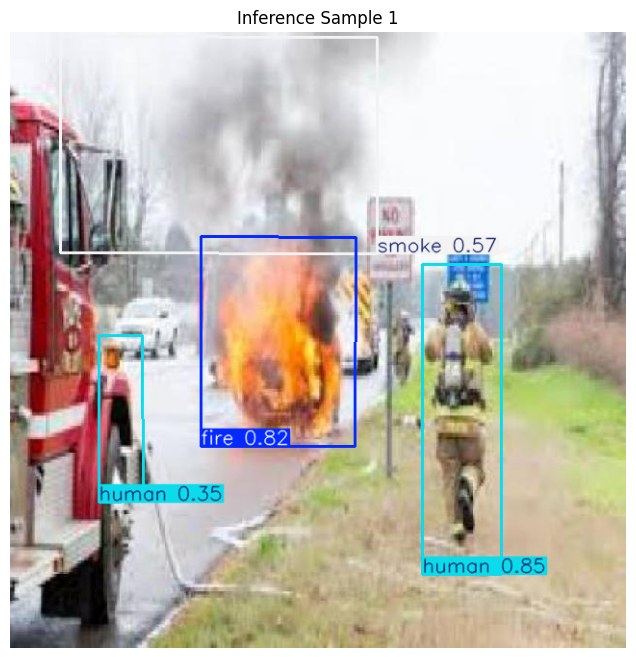

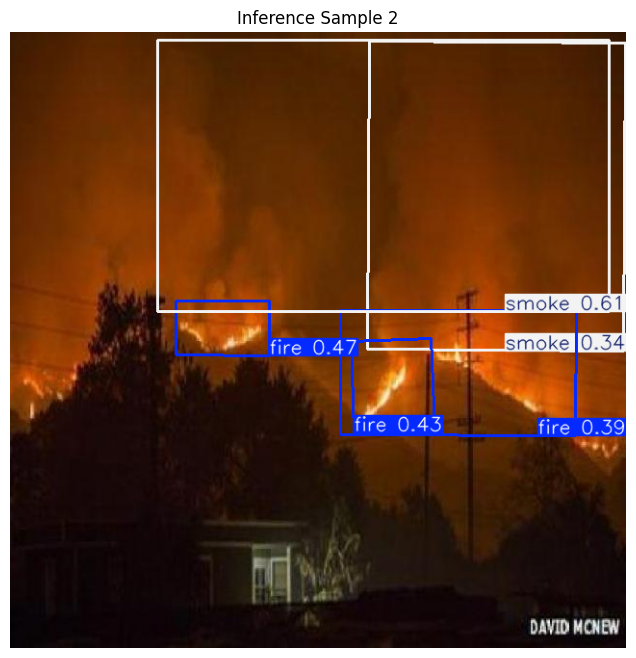

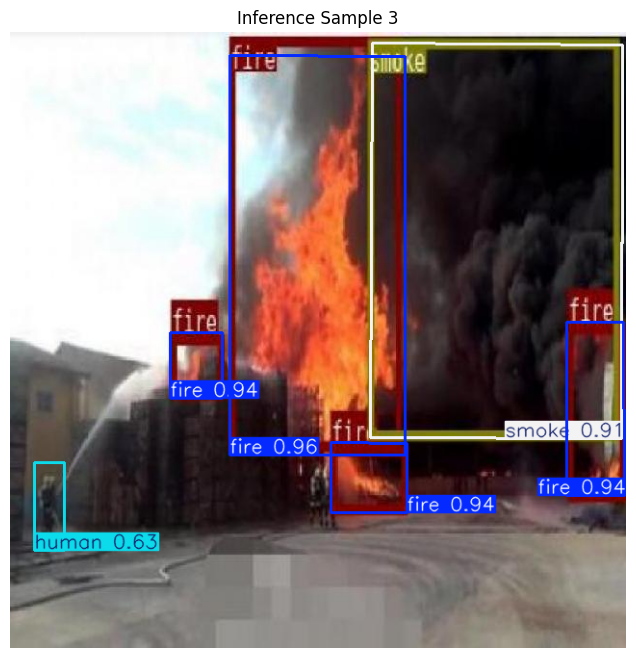

In [ ]:
import random
from PIL import Image

# Run inference on 3 random images from the test set
test_images = glob.glob('/content/dataset/test/images/*.jpg')
sample_images = random.sample(test_images, 3)

# Load the best model
best_model = YOLO('/content/runs/obb/yolov8_obb_fire_smoke-4/weights/best.pt')

# Predict and plot
results = best_model.predict(source=sample_images, imgsz=640)

for i, r in enumerate(results):
    im_array = r.plot()  # plot a BGR numpy array of predictions
    im = Image.fromarray(im_array[..., ::-1])  # RGB PIL image
    plt.figure(figsize=(8, 8))
    plt.imshow(im)
    plt.axis('off')
    plt.title(f'Inference Sample {i+1}')
    plt.show()

### Upload and Test Your Own Images
Run the cell below to upload images from your local machine and see the model's detections.

Saving stock-photo-professional-chef-creating-flamb-flame-while-cooking-in-a-restaurant-kitchen-concept-of-high-2753552019.jpg to stock-photo-professional-chef-creating-flamb-flame-while-cooking-in-a-restaurant-kitchen-concept-of-high-2753552019.jpg

0: 480x640 1 fire, 18.9ms
Speed: 5.2ms preprocess, 18.9ms inference, 3.4ms postprocess per image at shape (1, 3, 480, 640)


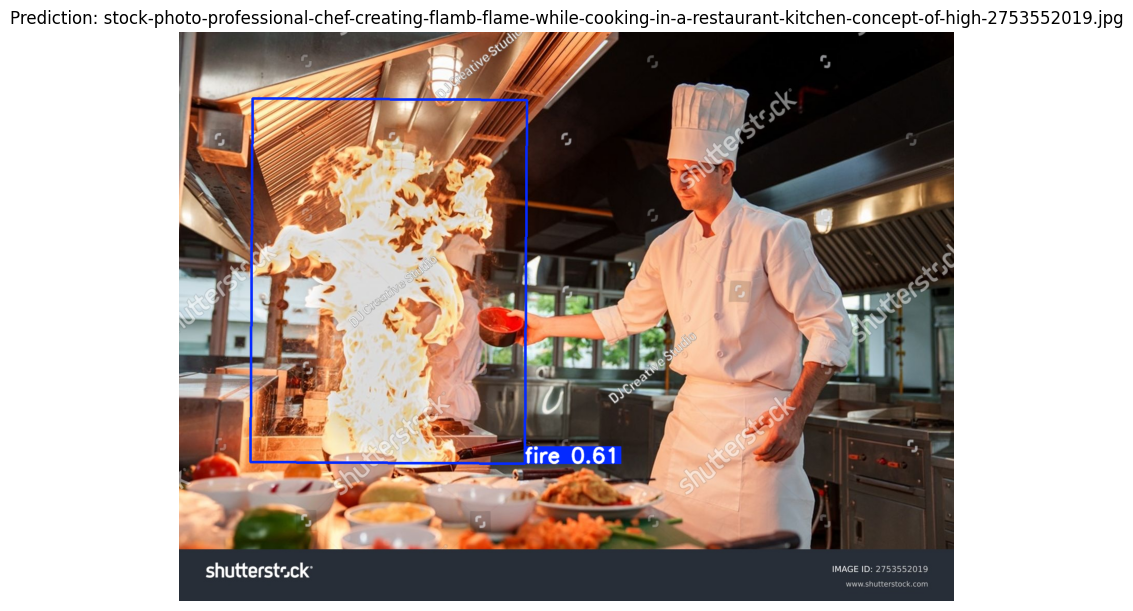

In [ ]:
from google.colab import files
import cv2
from PIL import Image
import matplotlib.pyplot as plt

# 1. Upload files
uploaded = files.upload()

# 2. Run inference on uploaded files
if uploaded:
    uploaded_paths = list(uploaded.keys())

    # Using the best_model loaded in the previous step
    results = best_model.predict(source=uploaded_paths, imgsz=640)

    # 3. Visualize results
    for i, r in enumerate(results):
        im_array = r.plot() # BGR array
        im_rgb = Image.fromarray(im_array[..., ::-1]) # Convert to RGB for PIL

        plt.figure(figsize=(10, 10))
        plt.imshow(im_rgb)
        plt.title(f"Prediction: {uploaded_paths[i]}")
        plt.axis('off')
        plt.show()